In [44]:
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

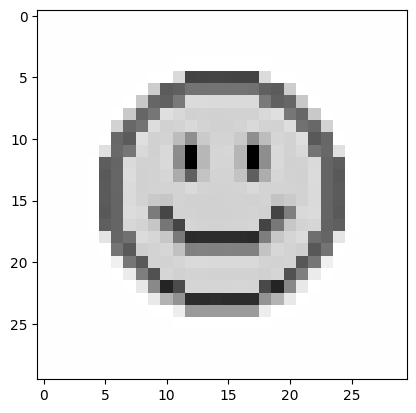

In [45]:
img = Image.open("images/emoji.png").convert("L")

img = img.resize((30, 30))

img = np.array(img, dtype=np.float32) / 255.0

H, W = img.shape

plt.imshow(img, cmap="gray")
plt.show()

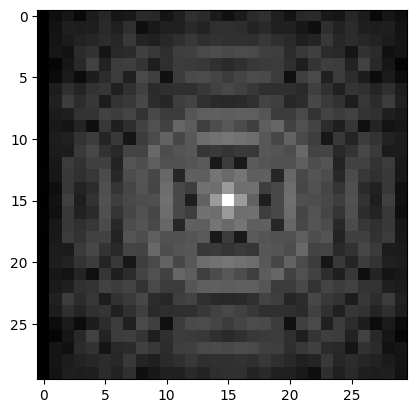

In [46]:
F = np.fft.fft2(img)

# Shift low frequencies to center
F_shift = np.fft.fftshift(F)

# Magnitude spectrum
magnitude = np.abs(F_shift)

log = (255/math.log(1+255)) * np.log1p(magnitude)

plt.imshow(log, cmap="gray")
plt.show()

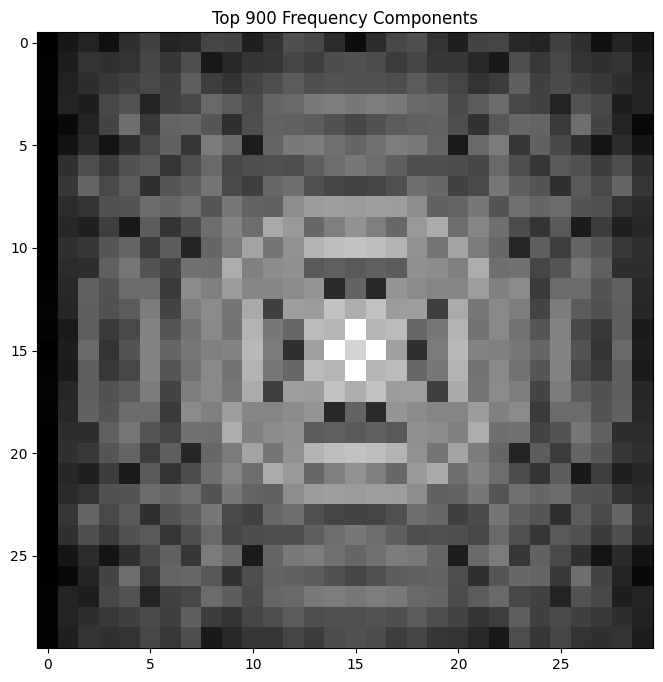

In [50]:
N_COMPONENTS = 900

flat_indices = np.argsort(magnitude.ravel())[::-1]
selected = flat_indices[:N_COMPONENTS]

reconstruction = np.zeros((H, W), dtype=np.complex128)

sinusoids = []
freq_coords = []

# merged visualization
merged_freq_vis = np.zeros((H, W))

for idx in selected:

    y, x = np.unravel_index(idx, (H, W))
    freq_coords.append((y, x))

    # sparse frequency representation
    temp = np.zeros_like(F_shift, dtype=np.complex128)

    temp[y, x] = F_shift[y, x]

    # symmetric component
    temp[(-y) % H, (-x) % W] = F_shift[(-y) % H, (-x) % W]

    # accumulate visualization
    merged_freq_vis += np.log1p(np.abs(temp))

    # convert to spatial sinusoid
    spatial = np.fft.ifft2(np.fft.ifftshift(temp))

    reconstruction += spatial
    sinusoids.append(np.real(spatial))

# final image
reconstruction = np.real(reconstruction)

# normalize reconstruction
reconstruction = (
    reconstruction - reconstruction.min()
) / (
    reconstruction.max() - reconstruction.min() + 1e-8
)

# normalize visualization
merged_freq_vis = (
    merged_freq_vis - merged_freq_vis.min()
) / (
    merged_freq_vis.max() - merged_freq_vis.min() + 1e-8
)

# show merged frequency map
plt.figure(figsize=(8, 8))
plt.imshow(merged_freq_vis, cmap="gray")
plt.title(f"Top {N_COMPONENTS} Frequency Components")
plt.show()

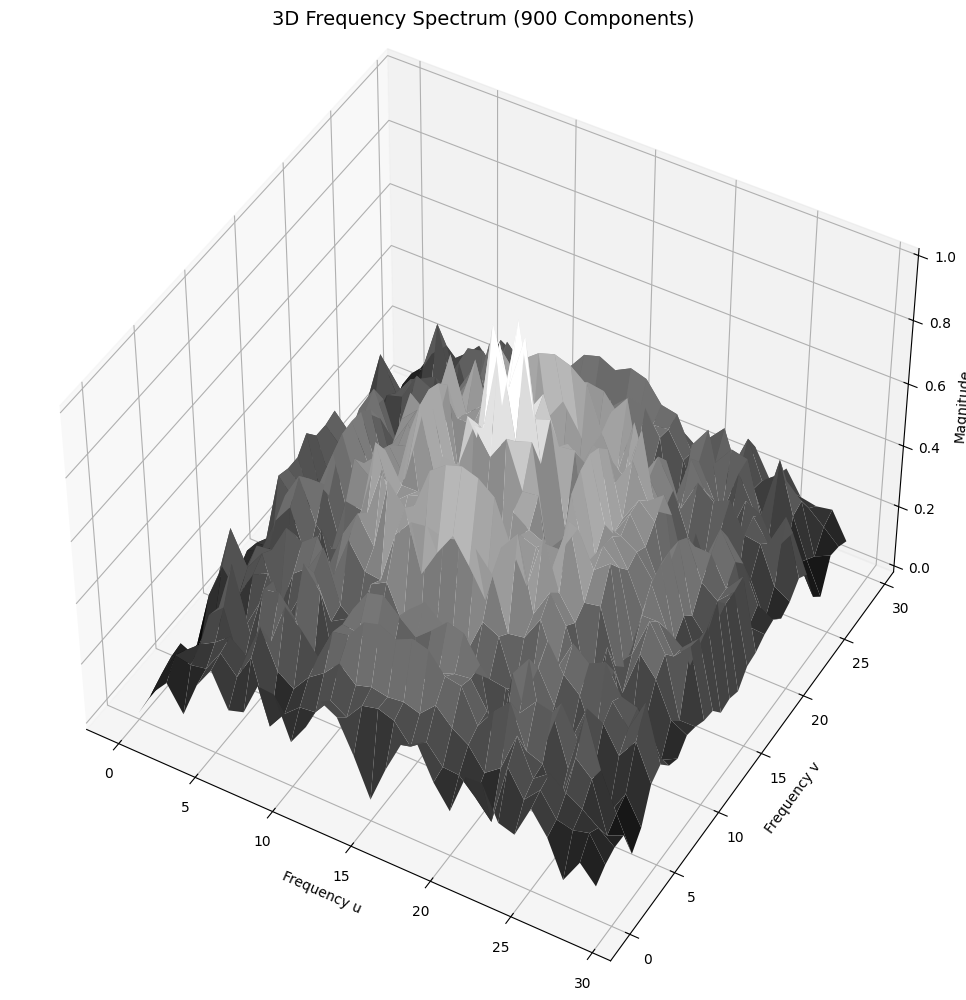

In [51]:
Y, X = np.meshgrid(
    np.arange(H),
    np.arange(W),
    indexing="ij"
)

# create figure
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection="3d")

# surface plot
ax.plot_surface(
    X,
    Y,
    merged_freq_vis,
    cmap="gray",
    linewidth=0,
    antialiased=True
)

# labels
ax.set_title(
    f"3D Frequency Spectrum ({N_COMPONENTS} Components)",
    fontsize=14
)

ax.set_xlabel("Frequency u")
ax.set_ylabel("Frequency v")
ax.set_zlabel("Magnitude")

# better viewing angle
ax.view_init(
    elev=45,
    azim=-60
)

plt.tight_layout()
plt.show()

In [52]:
TOTAL = N_COMPONENTS + 3   # original + spectrum + reconstruction

cols = 5
rows = int(np.ceil(TOTAL / cols))

fig = plt.figure(figsize=(18, rows * 3))

# --------------------------------------------
# Original Image
# --------------------------------------------

plt.subplot(rows, cols, 1)

plt.imshow(img, cmap="gray")

plt.title("Original")

plt.axis("off")

# --------------------------------------------
# Frequency Spectrum
# --------------------------------------------

plt.subplot(rows, cols, 2)

plt.imshow(np.log1p(magnitude), cmap="gray")

plt.title("Spectrum")

plt.axis("off")

# --------------------------------------------
# Reconstruction
# --------------------------------------------

plt.subplot(rows, cols, 3)

plt.imshow(reconstruction, cmap="gray")

plt.title("Reconstruction")

plt.axis("off")

# --------------------------------------------
# All Sinusoids
# --------------------------------------------

for i in range(N_COMPONENTS):

    s = sinusoids[i]

    s = (s - s.min()) / (s.max() - s.min() + 1e-8)

    y, x = freq_coords[i]

    # optional: shift to centered frequency coordinates
    u = x - W // 2
    v = y - H // 2

    plt.subplot(rows, cols, i + 4)

    plt.imshow(s, cmap="gray")

    plt.title(f"({u},{v})")

    plt.axis("off")

plt.tight_layout()

plt.show()